In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.samplers import RandomSampler
from Testing.RTLO import *
from Testing.Cloud import *
from Testing.AutoCloud import *
from Functions.RLS import *
from Functions.Utils import *
from Functions.TedaGraphs import *
from Functions.Graphs import *

dir_hi = r"C:\Artigo_J3C_V2\VMD10\HI"
dir_rs = r"C:\Artigo_J3C_V2\VMD10\RS6_def\S2_A1_Q10_W10_RS_raw\RS1"
brng = 'Bearing1_1.csv'
brngs1 = ['Bearing1_1.csv','Bearing2_2.csv','Bearing1_2.csv','Bearing1_3.csv','Bearing2_5.csv']
Mp=[1.9249999999999998, 10, 8, True]
Mp2 = [1e-7,	0.1,	0.01,	1e-7,	18,	3,	24]
m, nRS, st, drop = Mp
D,N1, N2, N3,nHI, nR,tau = Mp2

In [ ]:
def objective(trial):
    m = trial.suggest_float('m', 1.4, 2.0,step=0.01)
    nRS = trial.suggest_int('nRS', 2, 15) 
    st = trial.suggest_int('st', 0, 1) 
    drop = trial.suggest_categorical('drop', [True, False]) 
    wta = trial.suggest_categorical('wta', [True, False]) 
    brngs = brngs1[:3]
    vgrnls,ngrnls = np.array([]),np.array([])
    init = (st+nRS)
    Grncreated = None
    lenRun=0

    for i,brng in enumerate(brngs):
        df_RS = (pd.read_csv(os.path.join(dir_rs,brng)).abs()).iloc[:,:-1]
        df_HI = (pd.read_csv(os.path.join(dir_hi,brng)).abs()).iloc[:,:-1]
        if drop: df_RS = df_RS.drop(columns='Y')
        RS = process_RS(df_RS,nRS)
        HI = process_HI(df_HI,nHI=nHI,init=init)
        xS,yS,zS = RS[st:-2], HI[:-1], HI[1:]
        
        if i==0: teda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), 
                            ηS= [N1, N2, N3], tau=tau, decay=D,eol=0.2,fator=1,
                            st=init,end=len(df_RS)-init,wta=wta,ep=0.1) 
        
        elif i>0: teda.reset_rul()

        for j,_ in enumerate(xS):
            x= xS[j]
            teda.run(X=x)
                
        if i == 0: 
            Grncreated = len(teda.c)
            trial.report(Grncreated, step=j + lenRun)
            if trial.should_prune(): raise optuna.TrialPruned()
    lenRun = len(RS)
    for cloud in teda.c[:]:
        cloud.CalcV()
        vgrnls = np.append(vgrnls,cloud.v)
    return np.sum(vgrnls)

pruner=optuna.pruners.ThresholdPruner(upper=6, lower=2)
study = optuna.create_study(
    direction="maximize",
    #storage="sqlite:///" + f'98_Optuna/{FileName}_Grnls.db',
    #study_name=f'P{7}',
    #sampler=RandomSampler(),
    pruner=pruner,
    load_if_exists=True)
study.optimize(objective, n_trials=200)
best_params = study.best_params
Mp = list(best_params.values())
print('Erro:', study.best_value, 'parameters: ', Mp)

[I 2026-03-13 15:51:18,487] A new study created in memory with name: no-name-9c6b72c0-76e1-4c28-b6ce-842e94a387af
[I 2026-03-13 15:51:18,509] Trial 0 finished with value: 0.5778100041754076 and parameters: {'m': 1.5999999999999999, 'nRS': 12, 'st': 1, 'drop': True}. Best is trial 0 with value: 0.5778100041754076.
[I 2026-03-13 15:51:18,516] Trial 1 pruned. 
[I 2026-03-13 15:51:18,544] Trial 2 finished with value: 0.584647618459441 and parameters: {'m': 1.54, 'nRS': 5, 'st': 1, 'drop': True}. Best is trial 2 with value: 0.584647618459441.
[I 2026-03-13 15:51:18,551] Trial 3 pruned. 
[I 2026-03-13 15:51:18,587] Trial 4 finished with value: 0.4716528559231194 and parameters: {'m': 1.44, 'nRS': 7, 'st': 0, 'drop': False}. Best is trial 2 with value: 0.584647618459441.
[I 2026-03-13 15:51:18,595] Trial 5 pruned. 
[I 2026-03-13 15:51:18,600] Trial 6 pruned. 
[I 2026-03-13 15:51:18,607] Trial 7 pruned. 
[I 2026-03-13 15:51:18,634] Trial 8 finished with value: 0.5844633395780086 and parameters

Erro: 0.5911777926292421 parameters:  [1.43, 15, 1, True]


In [3]:
Mp = [1.43, 15, 1, True]

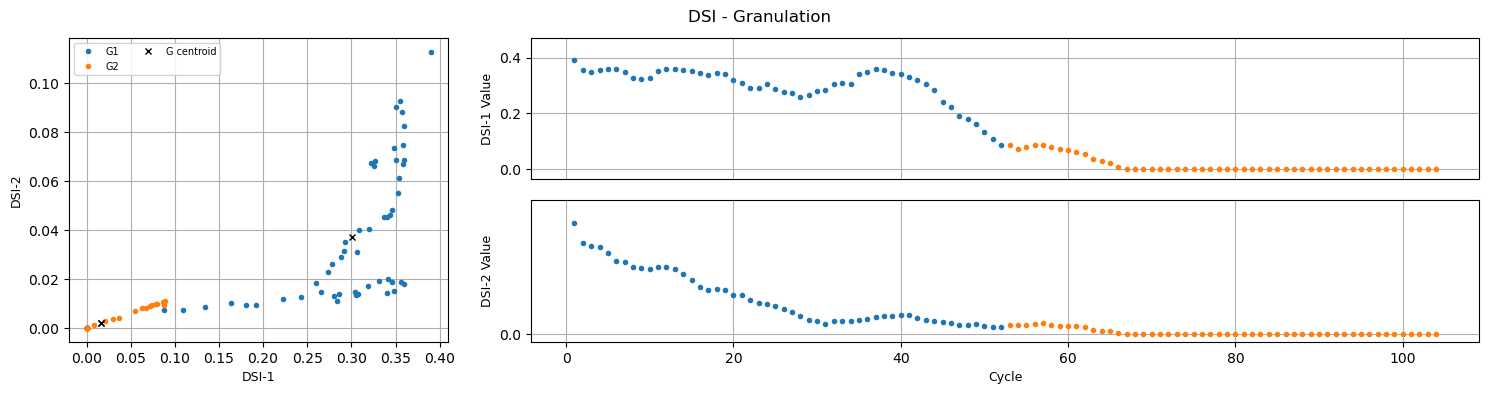

In [2]:
m, nRS, st, drop = Mp

init = (st+nRS)
df_RS = (pd.read_csv(os.path.join(dir_rs,brngs1[0])).abs()).iloc[:,:-1]
df_HI = (pd.read_csv(os.path.join(dir_hi,brngs1[0])).abs()).iloc[:,-1:]
if drop: df_RS = df_RS.drop(columns='Y')
RS = process_RS(df_RS,nRS)
HI = process_HI(df_HI,nHI=nHI,init=init)
xS,yS,zS = RS[st:-2], HI[:-1], HI[1:]

teda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), 
                            ηS= [N1, N2, N3], tau=tau, decay=D,eol=0.2,
                            fator=1,st=init,end=len(df_RS)-init,wta=False,ep=0.1) 

for j,_ in enumerate(xS[:]):
    x,y,z= xS[j],yS[j],zS[j]
    teda.run(x)

plot_DSI2(teda,ftrs=2,title='DSI - Granulation',ncol=2)

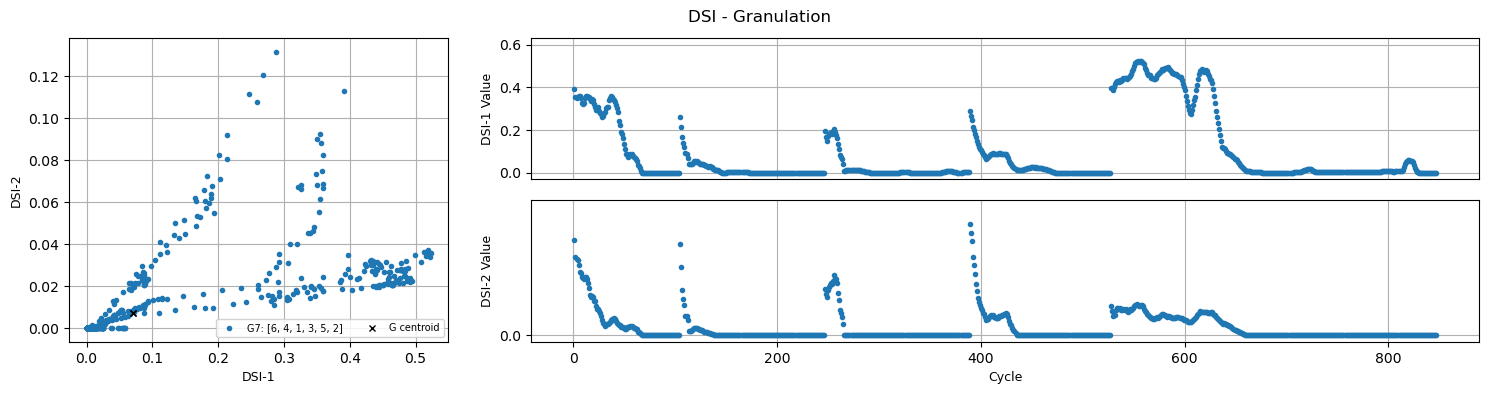

In [8]:
m, nRS, st, drop = Mp

for i,brng in enumerate(brngs1[:]):
    df_RS = (pd.read_csv(os.path.join(dir_rs,brng)).abs()).iloc[:,:-1]
    df_HI = (pd.read_csv(os.path.join(dir_hi,brng)).abs()).iloc[:,:-1]
    if drop: df_RS = df_RS.drop(columns='Y')
    RS = process_RS(df_RS,nRS)
    HI = process_HI(df_HI,nHI=nHI,init=init)
    xS,yS,zS = RS[st:-2], HI[:-1], HI[1:]
    
    if i==0: teda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), 
                        ηS= [N1, N2, N3], tau=tau, decay=D,eol=0.2,fator=1,
                        st=init,end=len(df_RS)-init,wta=True,ep=0.1) 
    
    elif i>0: teda.reset_rul()

    for j,_ in enumerate(xS):
        x= xS[j]
        teda.run(X=x)

plot_DSI2(teda,ftrs=2,title='DSI - Granulation',ncol=2)